# Isotropic Ratio: First & Second Derivatives — User-Defined Polygon

**Paper:** *A Computational Approach to Understanding The Isotropic Ratio on Polygons* (Chai, advised by Van Handel)

This notebook computes all 20 building-block equations for
$$f_W(t) = \frac{\mathrm{Vol}(P_{t,W})^{2n+2}}{\det\bar{C}(P_{t,W})}, \qquad n=2,$$
then assembles
$$f_W'(0) = \frac{d}{dt}f_W(t)\Big|_{t=0}, \qquad f_W''(0) = \frac{d^2}{dt^2}f_W(t)\Big|_{t=0}.$$

**Usage:** Edit the two cells in Section 0 to supply your polygon vertices and perturbation vectors, then run *Kernel → Restart & Run All*.

Every function is annotated with the equation number from the paper.

---
## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import ConvexHull

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

# If you do not have a package installed locally you can run,
'%pip install package_name'

'%pip install package_name'

---
## Section 0 · User Input

### 0a — Polygon Vertices

Supply the vertices of a **convex** polygon in **clockwise** order.  
Each row is `[x, y]`.  The origin must lie in the interior.

> **Tip:** uncomment one of the preset examples, or replace with your own vertices.

In [2]:
# ── PRESET: square (side 2a, a=1) ─────────────────────────────────────────────
# vertices_input = np.array([
#     [-1,  1],   # v0
#     [ 1,  1],   # v1
#     [ 1, -1],   # v2
#     [-1, -1],   # v3
# ], dtype=float)

# ── PRESET: equilateral triangle ───────────────────────────────────────────────
# vertices_input = np.array([
#     [ 0.0,  1.0],
#     [ 0.866, -0.5],
#     [-0.866, -0.5],
# ], dtype=float)

# ── PRESET: regular pentagon ──────────────────────────────────────────────────
# angles = np.linspace(0, 2*np.pi, 5, endpoint=False)
# vertices_input = np.column_stack([np.cos(angles), np.sin(angles)])[::-1]

# ── YOUR POLYGON (default: square) ────────────────────────────────────────────
vertices_input = np.array([
    [-1,  1],
    [ 1,  1],
    [ 1, -1],
    [-1, -1],
], dtype=float)

### 0b — Perturbation Vectors

Supply one perturbation vector $w_i$ per **facet** (same count as vertices).  
Facet $F_i$ connects vertex $v_i$ to $v_{i+1}$.  
Set $w_i = (0,0)$ to leave a facet unperturbed.

In [3]:
# ── PRESET: perturb only facet F0 in the x-direction (paper's square example) ─
# W_input = np.array([
#     [1, 0],   # w0  ← only this facet is perturbed
#     [0, 0],   # w1
#     [0, 0],   # w2
#     [0, 0],   # w3
# ], dtype=float)

# ── YOUR PERTURBATIONS (default matches above preset) ─────────────────────────
W_input = np.array([
    [1, 0],
    [0, 0],
    [0, 0],
    [0, 0],
], dtype=float)

# ─────────────────────────────────────────────────────────────────────────────
# The next cell validates and canonicalises your input automatically.
# Do NOT edit below this line in Section 0.
# ─────────────────────────────────────────────────────────────────────────────

---
## Section 1 · Validation & Polygon Rendering

✓ Polygon accepted: 4 vertices, clockwise orientation, origin in interior.


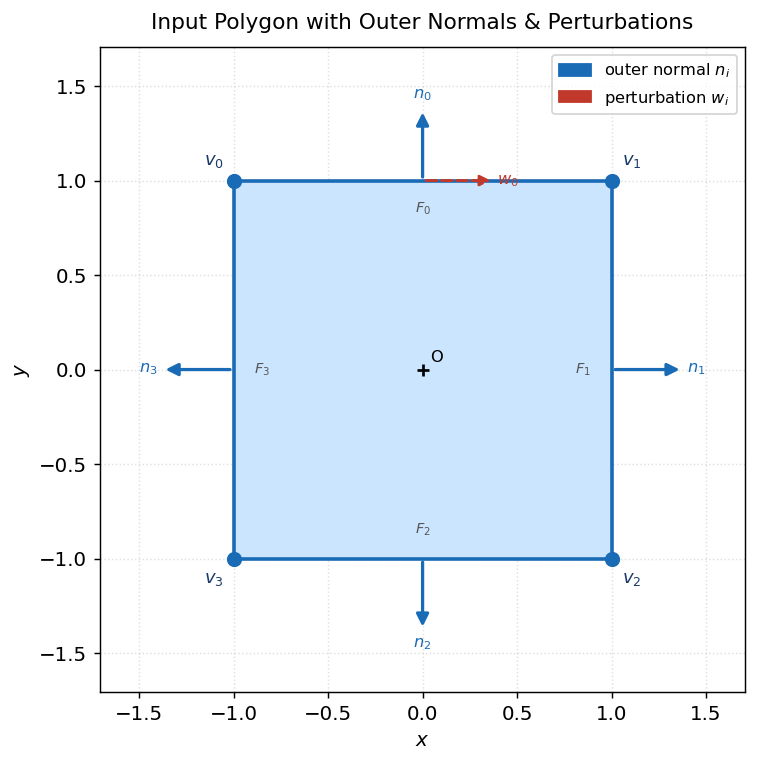


Vertices (clockwise):
[[-1.  1.]
 [ 1.  1.]
 [ 1. -1.]
 [-1. -1.]]

Outer normals (scaled so <n_i, v_i>=1):
[[-0.  1.]
 [ 1.  0.]
 [-0. -1.]
 [-1.  0.]]

Perturbation matrix W:
[[1. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [4]:
def canonicalise_polygon(verts_raw):
    """
    Given an (m,2) array of polygon vertices:
      1. Enforce clockwise orientation.
      2. Compute H-representation normals n_i scaled so <n_i, v_i> = 1.
    Returns (verts_cw, normals).
    """
    verts = np.array(verts_raw, dtype=float)
    m = len(verts)


    # Signed area via shoelace; negative => clockwise in standard (y-up) coords. One could also use the MGF 
    signed_area = 0.5 * sum(
        verts[i, 0] * verts[(i+1) % m, 1] - verts[(i+1) % m, 0] * verts[i, 1]
        for i in range(m)
    )
    if signed_area > 0:          # counter-clockwise → reverse
        verts = verts[::-1].copy()

    centroid = verts.mean(0)    # for uniform-density polygons the centroid corresponds to the barycenter
    normals = np.zeros((m, 2))
    for i in range(m):
        j  = (i + 1) % m
        dx = verts[j, 0] - verts[i, 0]
        dy = verts[j, 1] - verts[i, 1]
        ni = np.array([-dy, dx])          # rotate 90° CW → points outward for CW polygon / finds the direction of n_i first
        mid = 0.5 * (verts[i] + verts[j])
        if np.dot(ni, mid - centroid) < 0:
            ni = -ni
        scale = np.dot(ni, verts[i])
        if abs(scale) < 1e-14:
            raise ValueError(f"Normal for facet {i} is degenerate (vertex on the line through the origin).")
        normals[i] = ni / scale           # then we scale n_i such that <n_i, v_i> = 1
    return verts, normals


def validate_inputs(verts_raw, W_raw):
    verts, normals = canonicalise_polygon(verts_raw)
    m = len(verts)
    W = np.array(W_raw, dtype=float)
    assert W.shape == (m, 2), (
        f"W_input must have shape ({m}, 2) — one perturbation per facet, got {W.shape}.")
    # Check origin is inside (all signed distances > 0)
    for i in range(m):
        j = (i+1) % m
        edge = verts[j] - verts[i]
        outward = np.array([-edge[1], edge[0]])
        if np.dot(outward, verts[i]) < 0:
            outward = -outward
        assert np.dot(outward, -verts[i]) < 0, \
            "Origin does not appear to be in the interior of the polygon."
    print(f"✓ Polygon accepted: {m} vertices, clockwise orientation, origin in interior.")
    return verts, normals, W


verts, normals, W = validate_inputs(vertices_input, W_input)
m = len(verts)


# ── Render ────────────────────────────────────────────────────────────────────
def render_polygon(verts, normals, W, title="Input Polygon with Outer Normals & Perturbations"):
    centroid = verts.mean(0)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12, pad=10)

    # Filled polygon
    poly_patch = plt.Polygon(verts, closed=True,
                             facecolor="#cce5ff", edgecolor="#1a6bb5",
                             linewidth=2, zorder=2)
    ax.add_patch(poly_patch)

    # Origin
    ax.scatter(0, 0, color="black", s=40, zorder=6, marker="+")
    ax.annotate("O", xy=(0,0), xytext=(0.04, 0.04), fontsize=9, color="black")

    # Vertex dots + labels
    for i, v in enumerate(verts):
        ax.scatter(*v, color="#1a6bb5", s=55, zorder=5)
        off = v - centroid
        off = off / (np.linalg.norm(off) + 1e-12) * 0.15
        ax.annotate(f"$v_{i}$", xy=v, xytext=v + off,
                    fontsize=10, ha="center", va="center",
                    color="#1a3a6b", zorder=6)

    pad_scale = 0.38
    for i in range(m):
        j   = (i + 1) % m
        mid = 0.5 * (verts[i] + verts[j])
        # Outer normal (blue)
        n_dir = normals[i].copy()
        n_dir = n_dir / (np.linalg.norm(n_dir) + 1e-12)
        n_end = mid + pad_scale * n_dir
        ax.annotate("", xy=n_end, xytext=mid,
                    arrowprops=dict(arrowstyle="-|>", color="#1a6bb5",
                                    lw=1.8, mutation_scale=14), zorder=7)
        ax.text(*(n_end + 0.07 * n_dir), f"$n_{i}$",
                fontsize=9, color="#1a6bb5", ha="center", va="center", zorder=8)

        # Perturbation vector (red dashed), if non-zero
        w_i = W[i]
        if np.linalg.norm(w_i) > 1e-12:
            w_dir = w_i / np.linalg.norm(w_i)
            w_end = mid + pad_scale * w_dir
            ax.annotate("", xy=w_end, xytext=mid,
                        arrowprops=dict(arrowstyle="-|>", color="#c0392b",
                                        lw=1.6, mutation_scale=12,
                                        linestyle="dashed"), zorder=7)
            ax.text(*(w_end + 0.07 * w_dir), f"$w_{i}$",
                    fontsize=9, color="#c0392b", ha="center", va="center", zorder=8)

        # Facet label
        in_dir = centroid - mid
        in_dir = in_dir / (np.linalg.norm(in_dir) + 1e-12) * 0.15
        ax.text(*(mid + in_dir), f"$F_{i}$",
                fontsize=8, color="#555", ha="center", va="center", zorder=3)

    pad = max(np.linalg.norm(verts, axis=1).max() * 0.5, 0.5)
    ax.set_xlim(verts[:, 0].min() - pad, verts[:, 0].max() + pad)
    ax.set_ylim(verts[:, 1].min() - pad, verts[:, 1].max() + pad)
    ax.set_xlabel("$x$", fontsize=11)
    ax.set_ylabel("$y$", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.4)

    normal_patch = mpatches.Patch(color="#1a6bb5", label="outer normal $n_i$")
    perturb_patch = mpatches.Patch(color="#c0392b", label="perturbation $w_i$")
    ax.legend(handles=[normal_patch, perturb_patch], loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()


render_polygon(verts, normals, W)
print(f"\nVertices (clockwise):\n{verts}")
print(f"\nOuter normals (scaled so <n_i, v_i>=1):\n{normals}")
print(f"\nPerturbation matrix W:\n{W}")

---
## Section 2 · Helper: Vertex Derivatives [Eq. 1 & 2]

Vertex $v_i$ is the intersection of facets $F_{i-1}$ and $F_i$, satisfying $N_i(t)\,v_i(t) = [1,1]^T$.

$$\frac{dv_i}{dt}\Big|_{t=0} = -N_i^{-1}W_i\,v_i \tag{Eq. 1}$$
$$\frac{d^2v_i}{dt^2}\Big|_{t=0} = 2N_i^{-1}W_iN_i^{-1}W_i\,v_i \tag{Eq. 2}$$

In [5]:
def N_mat(normals, i):
    """N_i = stack of n_{i-1} and n_i  (Lemma on vertex derivatives)."""
    return np.array([normals[(i - 1) % m], normals[i]])

def W_mat(W, i):
    """W_i = stack of w_{i-1} and w_i."""
    return np.array([W[(i - 1) % m], W[i]])

def dvi(i):
    """Eq. 1: first derivative of vertex i at t=0."""
    Ni = N_mat(normals, i)
    Wi = W_mat(W, i)
    return -np.linalg.solve(Ni, Wi @ verts[i])

def d2vi(i):
    """Eq. 2: second derivative of vertex i at t=0."""
    Ni = N_mat(normals, i)
    Wi = W_mat(W, i)
    return 2 * np.linalg.solve(Ni, Wi @ np.linalg.solve(Ni, Wi @ verts[i]))

# Precompute all vertex derivatives
vd  = np.array([dvi(i)   for i in range(m)])   # shape (m, 2)
vdd = np.array([d2vi(i)  for i in range(m)])   # shape (m, 2)

print("Vertex first derivatives  v'_i  [Eq. 1]:")
for i in range(m):
    print(f"  v'{i} = {vd[i]}")

print("\nVertex second derivatives v''_i [Eq. 2]:")
for i in range(m):
    print(f"  v''{i} = {vdd[i]}")

Vertex first derivatives  v'_i  [Eq. 1]:
  v'0 = [0. 1.]
  v'1 = [-0. -1.]
  v'2 = [-0.  0.]
  v'3 = [0. 0.]

Vertex second derivatives v''_i [Eq. 2]:
  v''0 = [-0.  0.]
  v''1 = [0. 0.]
  v''2 = [ 0. -0.]
  v''3 = [-0. -0.]


---
## Section 3 · Triangle Moment

Fan triangulation: $\triangle_i = \triangle(v_0, v_i, v_{i+1})$ for $1 \le i \le m-2$.  
The matrix $A_i = [v_{i+1}-v_0 \;|\; v_i-v_0]$ (columns).

Exact integrals over $\triangle(v_0,v_{i},v_{i+1})$:
$$\int_{\triangle_i} \langle z,p\rangle^s\,dp = \mathrm{Area}\cdot\begin{cases} 1 & s=0 \\ \tfrac{c+a_i+b_i}{3} & s=1 \\ \tfrac{c^2+a_i^2+b_i^2+ca_i+cb_i+a_ib_i}{6} & s=2 \end{cases}$$ 
just a re-expression of Eq. 7

In [ ]:
# vid = \frac{d}{dt}v_i,  vidd = \frac{d^2}{dt^2}v_i

'''

def tri_moment(v0, vi, vip, z, s):
    """int_{tri(v0,vi,vip)} <z,p>^s dp  for s in {0,1,2}."""
    ab, ac = vi - v0, vip - v0
    area = abs(ab[0]*ac[1] - ab[1]*ac[0]) / 2.0 # Area of triangle i = |detA_i|/2
    c, a, b = np.dot(z, v0), np.dot(z, vi), np.dot(z, vip)
    if   s == 0: return area
    elif s == 1: return area * (c + a + b) / 3.0
    else:        return area * (c**2 + a**2+ b**2 + c*a + c*b + a*b) / 6.0


def dtri_moment(v0, v0d, vi, vid, vip, vipd, z, s):
    """d/dt  tri_moment  at t=0."""
    ab, ac = vi-v0, vip-v0
    abd, acd = vid-v0d, vipd-v0d
    sgn   = np.sign(ab[0]*ac[1] - ab[1]*ac[0])
    area  = abs(ab[0]*ac[1] - ab[1]*ac[0]) / 2.0
    darea = sgn*(abd[0]*ac[1] + ab[0]*acd[1] - abd[1]*ac[0] - ab[1]*acd[0]) / 2.0
    a0,  a1,  a2  = np.dot(z,v0),  np.dot(z,vi),  np.dot(z,vip)
    a0d, a1d, a2d = np.dot(z,v0d), np.dot(z,vid), np.dot(z,vipd)
    if   s == 0: return darea
    elif s == 1: return darea*(a0+a1+a2)/3. + area*(a0d+a1d+a2d)/3.
    else:
        f  = (a0**2 + a1**2 + a2**2 + a0*a1 + a0*a2 + a1*a2) / 6.
        fd = (2*a0*a0d + 2*a1*a1d + 2*a2*a2d
              + a0d*a1 + a0*a1d + a0d*a2 + a0*a2d + a1d*a2 + a1*a2d) / 6.
        return darea*f + area*fd


def d2tri_moment(v0, v0d, v0dd, vi, vid, vidd, vip, vipd, vipdd, z, s):
    """d^2/dt^2  tri_moment  at t=0."""
    ab, ac   = vi-v0, vip-v0
    abd, acd = vid-v0d, vipd-v0d
    abdd, acdd = vidd-v0dd, vipdd-v0dd
    sgn    = np.sign(ab[0]*ac[1] - ab[1]*ac[0])
    area   = abs(ab[0]*ac[1] - ab[1]*ac[0]) / 2.
    darea  = sgn*(abd[0]*ac[1] + ab[0]*acd[1] - abd[1]*ac[0] - ab[1]*acd[0]) / 2.
    d2area = sgn*(abdd[0]*ac[1] + ab[0]*acdd[1] - abdd[1]*ac[0] - ab[1]*acdd[0]
                  + 2*(abd[0]*acd[1] - abd[1]*acd[0])) / 2.
    a0,  a1,  a2   = np.dot(z,v0),  np.dot(z,vi),  np.dot(z,vip)
    a0d, a1d, a2d  = np.dot(z,v0d), np.dot(z,vid), np.dot(z,vipd)
    a0dd,a1dd,a2dd = np.dot(z,v0dd),np.dot(z,vidd),np.dot(z,vipdd)
    if   s == 0: return d2area
    elif s == 1:
        f   = (a0+a1+a2)/3.
        fd  = (a0d+a1d+a2d)/3.
        fdd = (a0dd+a1dd+a2dd)/3.
        return d2area*f + 2*darea*fd + area*fdd
    else:
        f   = (a0**2+a1**2+a2**2+a0*a1+a0*a2+a1*a2)/6.
        fd  = (2*a0*a0d+2*a1*a1d+2*a2*a2d
               + a0d*a1+a0*a1d+a0d*a2+a0*a2d+a1d*a2+a1*a2d)/6.
        fdd = (2*(a0d**2+a0*a0dd)+2*(a1d**2+a1*a1dd)+2*(a2d**2+a2*a2dd)
               +(a0dd*a1+2*a0d*a1d+a0*a1dd)+(a0dd*a2+2*a0d*a2d+a0*a2dd)
               +(a1dd*a2+2*a1d*a2d+a1*a2dd))/6.
        return d2area*f + 2*darea*fd + area*fdd

'''
def triangle_data(v0, v0d, v0dd, vi, vid, vidd, vip, vipd, vipdd, z):
    """
    Build the quantities appearing in the paper for one triangle:
        triangle_i = triangle(v0, vi, vip)

    a_i = <z, vi>
    b_i = <z, vip>
    c   = <z, v0>
    """

    A = np.column_stack((vip - v0, vi - v0))
    Ad = np.column_stack((vipd - v0d, vid - v0d))
    Add = np.column_stack((vipdd - v0dd, vidd - v0dd))

    detA = np.linalg.det(A)
    Ainv = np.linalg.inv(A)

    M = Ainv @ Ad
    p = np.trace(M)
    pd = np.trace(-Ainv @ Ad @ Ainv @ Ad + Ainv @ Add)

    a = np.dot(z, vi)
    b = np.dot(z, vip)
    c = np.dot(z, v0)

    ad = np.dot(z, vid)
    bd = np.dot(z, vipd)
    cd = np.dot(z, v0d)

    add = np.dot(z, vidd)
    bdd = np.dot(z, vipdd)
    cdd = np.dot(z, v0dd)

    S = a + b + c
    Sd = ad + bd + cd
    Sdd = add + bdd + cdd

    Q = (a*a + b*b + c*c) + (b*a + c*b + a*c)

    Qd = (
        2*(a*ad + b*bd + c*cd)
        + bd*(a + c)
        + ad*(b + c)
        + cd*(b + a)
    )

    T = b + c + 2*a
    U = a + c + 2*b
    V = b + a + 2*c

    Td = bd + cd + 2*ad
    Ud = ad + cd + 2*bd
    Vd = bd + ad + 2*cd

    Qdd = (
        add*T + bdd*U + cdd*V
        + ad*Td + bd*Ud + cd*Vd
    )

    return {
        "A": A,
        "Ad": Ad,
        "Add": Add,
        "detA": detA,
        "abs_detA": abs(detA),
        "p": p,
        "pd": pd,
        "S": S,
        "Sd": Sd,
        "Sdd": Sdd,
        "Q": Q,
        "Qd": Qd,
        "Qdd": Qdd,
    }


def tri_moment(v0, vi, vip, z, s):
    """
    Implements Eq. 6 and Eq. 7 directly for one triangle.

    For triangle_i = triangle(v0, vi, vip),

        s = 0: Area = |det A_i| / 2
        s = 1: (1/6)|det A_i| S_i
        s = 2: (1/12)|det A_i| Q_i
    """

    zero = np.zeros_like(v0)

    data = triangle_data(
        v0, zero, zero,
        vi, zero, zero,
        vip, zero, zero,
        z
    )

    abs_detA = data["abs_detA"]

    if s == 0:
        return 0.5 * abs_detA

    elif s == 1:
        return (1.0 / 6.0) * abs_detA * data["S"]

    elif s == 2:
        return (1.0 / 12.0) * abs_detA * data["Q"]

    else:
        raise ValueError("This function only supports s = 0, 1, 2.")


def dtri_moment(v0, v0d, vi, vid, vip, vipd, z, s):
    """
    Implements Eq. 8 and Eq. 9 directly for one triangle.

    s = 0 gives the first derivative of triangle area:
        (1/2)(det A_i) p_i

    s = 1:
        (1/6)(det A_i)(p_i S_i + S_i')

    s = 2:
        (1/12)(det A_i)(p_i Q_i + Q_i')
    """

    zero = np.zeros_like(v0)

    data = triangle_data(
        v0, v0d, zero,
        vi, vid, zero,
        vip, vipd, zero,
        z
    )

    detA = data["detA"]
    p = data["p"]

    if s == 0:
        return 0.5 * detA * p   # equivalent form of V'

    elif s == 1:
        return (1.0 / 6.0) * detA * (
            p * data["S"] + data["Sd"]
        )

    elif s == 2:
        return (1.0 / 12.0) * detA * (
            p * data["Q"] + data["Qd"]
        )

    else:
        raise ValueError("This function only supports s = 0, 1, 2.")


def d2tri_moment(v0, v0d, v0dd, vi, vid, vidd, vip, vipd, vipdd, z, s):
    """
    Implements Eq. 13, Eq. 15, and Eq. 16 directly for one triangle.

    s = 0:
        (1/2)(det A_i)(p_i^2 + p_i')

    s = 1:
        (1/6)(det A_i)[2p_i S_i' + (p_i^2+p_i')S_i + S_i'']

    s = 2:
        (1/12)(det A_i)[Q_i(p_i^2+p_i') + 2p_i Q_i' + Q_i'']
    """

    data = triangle_data(
        v0, v0d, v0dd,
        vi, vid, vidd,
        vip, vipd, vipdd,
        z
    )

    detA = data["detA"]
    p = data["p"]
    pd = data["pd"]

    if s == 0:
        return 0.5 * detA * (p*p + pd)  # equivalent form of V''

    elif s == 1:
        return (1.0 / 6.0) * detA * (
            2*p*data["Sd"]
            + (p*p + pd)*data["S"]
            + data["Sdd"]
        )

    elif s == 2:
        return (1.0 / 12.0) * detA * (
            data["Q"]*(p*p + pd)
            + 2*p*data["Qd"]
            + data["Qdd"]
        )

    else:
        raise ValueError("This function only supports s = 0, 1, 2.")
print("Triangle moment kernels defined (s=0,1,2; 0th/1st/2nd t-derivatives).")

Triangle moment kernels defined (s=0,1,2; 0th/1st/2nd t-derivatives).


---
## Section 4 · Polygon Moment Integrals (via fan triangulation)

$$\int_P \langle z,p\rangle^s\,dp = \sum_{i=1}^{m-2}\int_{\triangle(v_0,v_i,v_{i+1})}\langle z,p\rangle^s\,dp$$

In [7]:
def moment(z, s):
    """int_P <z,p>^s dp via fan triangulation."""
    return sum(tri_moment(verts[0], verts[i], verts[i+1], z, s)
               for i in range(1, m-1))

def moment_prime(z, s):
    """d/dt  int_P <w,p>^s dp  at t=0."""
    p0, p0d = verts[0], vd[0]
    return sum(dtri_moment(p0, p0d, verts[i], vd[i], verts[i+1], vd[i+1], z, s)
               for i in range(1, m-1))

def moment_double_prime(z, s):
    """d^2/dt^2  int_P <z,p>^s dp  at t=0."""
    p0, p0d, p0dd = verts[0], vd[0], vdd[0]
    return sum(d2tri_moment(p0, p0d, p0dd,
                            verts[i],   vd[i],   vdd[i],
                            verts[i+1], vd[i+1], vdd[i+1], z, s)
               for i in range(1, m-1))


print("Polygon moment integral functions defined.")

Polygon moment integral functions defined.


---
## Section 5 · Assemble the Covariance-Like Matrix $\bar{C}$ [Eq. 3, 6, 7, 10]

$$V = \int_P dp = \frac{1}{2}\sum_{i=1}^{m-2}|\det A_i| \tag{Eq. 3}$$
$$\bar{C}(P) = V\int_P pp^T\,dp - \left(\int_P p\,dp\right)\left(\int_P p^T\,dp\right) \tag{Eq. 10}$$

We recover $\bar{C}$ from its quadratic form $z^T\bar{C}z = V\int_P\langle z,p\rangle^2\,dp - \left(\int_P\langle z,p\rangle\,dp\right)^2$  
evaluated at $z=e_1, e_2, e_1+e_2$ as $\bar{C}_{ij}=\frac{1}{2}(\langle e_i+e_j, \bar{C}(e_i+e_j)\rangle - \langle e_1,\bar{C}e_1 \rangle - \langle e_j,\bar{C}e_j \rangle)$.

In [ ]:

def qform_to_matrix(qf_e1, qf_e2, qf_e1e2):
    """
    Recover symmetric 2x2 matrix M from three quadratic form evaluations:
      qf_e1    = e1^T M e1  = M[0,0]
      qf_e2    = e2^T M e2  = M[1,1]
      qf_e1e2  = (e1+e2)^T M (e1+e2) = M[0,0]+2*M[0,1]+M[1,1]
    """
    M00 = qf_e1
    M11 = qf_e2
    M01 = (qf_e1e2 - M00 - M11) / 2.0
    return np.array([[M00, M01], [M01, M11]])


def compute_Cbar(Vval, moment_fn):
    """
    Build the (2x2) C-bar matrix given a volume scalar and moment function.
    moment_fn(z, s) must return  int_P <z,p>^s dp (or a derivative thereof).
    """
    e1, e2 = np.array([1.,0.]), np.array([0.,1.])
    e12 = e1 + e2

    def qf(z):
        I1z = moment_fn(z, 1)
        I2z = moment_fn(z, 2)
        return Vval * I2z - I1z**2  # comes from Eq. 10 in paper

    return qform_to_matrix(qf(e1), qf(e2), qf(e12))


# ── Eq. 3: Volume ─────────────────────────────────────────────────────────────
V = moment(np.array([1.,0.]), 0)   # works for any w since s=0

# ── Eq. 10: C-bar ─────────────────────────────────────────────────────────────
Cbar = compute_Cbar(V, moment)

D = np.linalg.det(Cbar)
Cbar_inv = np.linalg.inv(Cbar)

print(f"Eq. 3  — Volume  V = {V:.6f}")
print(f"Eq. 10 — C-bar matrix:")
print(f"         [[{Cbar[0,0]:.6f}, {Cbar[0,1]:.6f}],")
print(f"          [{Cbar[1,0]:.6f}, {Cbar[1,1]:.6f}]]")
print(f"         det(C-bar) D = {D:.6f}")

Eq. 3  — Volume  V = 4.000000
Eq. 10 — C-bar matrix:
         [[5.333333, 0.000000],
          [0.000000, 5.333333]]
         det(C-bar) D = 28.444444


---
## Section 6 · First Derivative Building Blocks [Eq. 4, 5, 6, 7, 8, 9, 11]

$$V' = \frac{1}{2}\sum_{i=1}^{m-2}|\det A_i|' \tag{Eq. 4}$$
$$I_1 =\int_P\langle z,p\rangle\,dp = \frac{1}{6}\sum_i|\det A_i|(a_i+b_i+c) \tag{Eq. 6}$$
$$I_2 =\int_P\langle z,p\rangle^2\,dp = \frac{1}{12}\sum_i|\det A_i|[(a_i^2+b_i^2+c^2)+(b_ia_i+c(b_i+a_i))] \tag{Eq. 7}$$

In [9]:
# ── Eq. 4: V' ─────────────────────────────────────────────────────────────────
Vp = moment_prime(np.array([1.,0.]), 0)

# ── Eq. 6 & 7: base moments (computed via moment(), checked against formula) ──
e1, e2 = np.array([1.,0.]), np.array([0.,1.])
I1_e1  = moment(e1, 1)
I1_e2  = moment(e2, 1)
I2_e1  = moment(e1, 2)
I2_e2  = moment(e2, 2)
I2_e12 = moment(e1+e2, 2)

# ── Eq. 8: (int <z,p> dp)' via moment_prime ───────────────────────────────────
I1p_e1  = moment_prime(e1, 1)
I1p_e2  = moment_prime(e2, 1)
I1p_e12 = moment_prime(e1+e2, 1)

# ── Eq. 9: (int <z,p>^2 dp)' via moment_prime ────────────────────────────────
I2p_e1  = moment_prime(e1, 2)
I2p_e2  = moment_prime(e2, 2)
I2p_e12 = moment_prime(e1+e2, 2)

# ── Eq. 11: C-bar' ────────────────────────────────────────────────────────────
def Cprime_qf(z):
    """z^T C' z  =  V' I2 + V I2' - 2 I1 I1'  [Eq. 11]"""
    I1z  = moment(z, 1)
    I2z  = moment(z, 2)
    I1pz = moment_prime(z, 1)
    I2pz = moment_prime(z, 2)
    return Vp*I2z + V*I2pz - 2*I1z*I1pz

Cbar_prime = qform_to_matrix(Cprime_qf(e1), Cprime_qf(e2), Cprime_qf(e1+e2))

print(f"Eq. 4  — V' = {Vp:.6f}")
print(f"Eq. 6  — int_P <e1,p> dp = {I1_e1:.6f}")
print(f"Eq. 6  — int_P <e2,p> dp = {I1_e2:.6f}")
print(f"Eq. 7  — int_P <e1,p>^2 dp = {I2_e1:.6f}")
print(f"Eq. 7  — int_P <e2,p>^2 dp = {I2_e2:.6f}")
print(f"Eq. 8  — (int_P <e1,p> dp)' = {I1p_e1:.6f}")
print(f"Eq. 9  — (int_P <e1,p>^2 dp)' = {I2p_e1:.6f}")
print(f"Eq. 11 — C-bar':")
print(f"         [[{Cbar_prime[0,0]:.6f}, {Cbar_prime[0,1]:.6f}],")
print(f"          [{Cbar_prime[1,0]:.6f}, {Cbar_prime[1,1]:.6f}]]")

Eq. 4  — V' = 0.000000
Eq. 6  — int_P <e1,p> dp = 0.000000
Eq. 6  — int_P <e2,p> dp = 0.000000
Eq. 7  — int_P <e1,p>^2 dp = 1.333333
Eq. 7  — int_P <e2,p>^2 dp = 1.333333
Eq. 8  — (int_P <e1,p> dp)' = -0.666667
Eq. 9  — (int_P <e1,p>^2 dp)' = 0.000000
Eq. 11 — C-bar':
         [[0.000000, -2.666667],
          [-2.666667, 0.000000]]


---
## Section 7 · First Derivative $f_W'(0)$ [Eq. 12, 18]

$$g = V\,\mathrm{tr}[\bar{C}^{-1}\bar{C}'] \tag{Eq. 18}$$

$$f_W'(0) = \frac{V^{2n+1}}{D}\left[(2n+2)V' - g\right], \quad n=2 \tag{Eq. 12}$$

In [10]:
n = 2   # dimension

# ── Eq. 18 ────────────────────────────────────────────────────────────────────
g = V * np.trace(Cbar_inv @ Cbar_prime)

# ── Eq. 12 ────────────────────────────────────────────────────────────────────
f_prime = (V**(2*n+1) / D) * ((2*n+2)*Vp - g)

print(f"Eq. 18 — g = {g:.6f}")
print()
print("━"*55)
print(f"  Eq. 12 — f_W'(0)  =  {f_prime:.8f}")
print("━"*55)

Eq. 18 — g = 0.000000

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Eq. 12 — f_W'(0)  =  0.00000000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Section 8 · Second Derivative Building Blocks [Eq. 13, 14, 15, 16, 17]

$$|\det A_i|'' = \det A_i\left[\mathrm{tr}(A_i^{-1}A_i')^2 + \mathrm{tr}(-A_i^{-1}A_i'A_i^{-1}A_i' + A_i^{-1}A_i'')\right] \tag{Eq. 13}$$

$$V'' = \frac{1}{2}\sum_i|\det A_i|'' \tag{Eq. 14}$$

In [11]:
# ── Eq. 13 & 14: V'' ──────────────────────────────────────────────────────────
Vpp = moment_double_prime(np.array([1.,0.]), 0)

# ── Eq. 15: (int <z,p> dp)'' ──────────────────────────────────────────────────
I1pp_e1  = moment_double_prime(e1, 1)
I1pp_e2  = moment_double_prime(e2, 1)
I1pp_e12 = moment_double_prime(e1+e2, 1)

# ── Eq. 16: (int <z,p>^2 dp)'' ───────────────────────────────────────────────
I2pp_e1  = moment_double_prime(e1, 2)
I2pp_e2  = moment_double_prime(e2, 2)
I2pp_e12 = moment_double_prime(e1+e2, 2)

# ── Eq. 17: C-bar'' ───────────────────────────────────────────────────────────
def Cdoubleprime_qf(z):
    """
    z^T C'' z = V'' I2 + 2V' I2' + V I2'' - 2[(I1')^2 + I1 I1'']   [Eq. 17]
    """
    I1z   = moment(z, 1)
    I2z   = moment(z, 2)
    I1pz  = moment_prime(z, 1)
    I2pz  = moment_prime(z, 2)
    I1ppz = moment_double_prime(z, 1)
    I2ppz = moment_double_prime(z, 2)
    return Vpp*I2z + 2*Vp*I2pz + V*I2ppz - 2*(I1pz**2 + I1z*I1ppz)

Cbar_double_prime = qform_to_matrix(
    Cdoubleprime_qf(e1), Cdoubleprime_qf(e2), Cdoubleprime_qf(e1+e2))

print(f"Eq. 14 — V'' = {Vpp:.6f}")
print(f"Eq. 15 — (int_P <e1,p> dp)'' = {I1pp_e1:.6f}")
print(f"Eq. 16 — (int_P <e1,p>^2 dp)'' = {I2pp_e1:.6f}")
print(f"Eq. 17 — C-bar'':")
print(f"         [[{Cbar_double_prime[0,0]:.6f}, {Cbar_double_prime[0,1]:.6f}],")
print(f"          [{Cbar_double_prime[1,0]:.6f}, {Cbar_double_prime[1,1]:.6f}]]")

Eq. 14 — V'' = 0.000000
Eq. 15 — (int_P <e1,p> dp)'' = 0.000000
Eq. 16 — (int_P <e1,p>^2 dp)'' = 0.000000
Eq. 17 — C-bar'':
         [[-0.888889, 0.000000],
          [0.000000, 5.333333]]


---
## Section 9 · Second Derivative $f_W''(0)$ [Eq. 19, 20]

$$\left(\frac{g}{V}\right)' = \mathrm{tr}\!\left[-\bar{C}^{-1}\bar{C}'\bar{C}^{-1}\bar{C}' + \bar{C}^{-1}\bar{C}''\right] \tag{Eq. 19}$$

$$f_W''(0) = \frac{V^{2n}}{D}\left[(2n+1)V'-g\right]\left[(2n+2)V'-g\right] + (2n+2)VV'' - V^2\left(\frac{g}{V}\right)' - gV', \quad n=2 \tag{Eq. 20}$$

In [12]:
# ── Eq. 19: (g/V)' ────────────────────────────────────────────────────────────
g_over_V_prime = np.trace(
    -Cbar_inv @ Cbar_prime @ Cbar_inv @ Cbar_prime
    + Cbar_inv @ Cbar_double_prime
)

# ── Eq. 20: f_W''(0) ──────────────────────────────────────────────────────────
f_double_prime = (V**(2*n) / D) * (
    ((2*n+1)*Vp - g) * ((2*n+2)*Vp - g)
    + (2*n+2) * V * Vpp
    - V**2 * g_over_V_prime
    - g * Vp
)

print(f"Eq. 19 — (g/V)' = {g_over_V_prime:.6f}")
print()
print("━"*55)
print(f"  Eq. 20 — f_W''(0) =  {f_double_prime:.8f}")
print("━"*55)

Eq. 19 — (g/V)' = 0.333333

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Eq. 20 — f_W''(0) =  -48.00000000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Section 10 · Full Summary

In [13]:
print("═"*65)
print("  ISOTROPIC RATIO DERIVATIVE SUMMARY")
print("═"*65)
print(f"  Polygon: {m} vertices")
print(f"  Vertices (CW):\n{verts}")
print(f"  Perturbation W:\n{W}")
print("─"*65)
print(f"  [Eq. 3]  Volume V               = {V:.8f}")
print(f"  [Eq. 4]  V'                      = {Vp:.8f}")
print(f"  [Eq. 14] V''                     = {Vpp:.8f}")
print(f"  [Eq. 10] det(C-bar)  D           = {D:.8e}")
print(f"  [Eq. 18] g = V·tr(C⁻¹·C')       = {g:.8f}")
print(f"  [Eq. 19] (g/V)'                  = {g_over_V_prime:.8f}")
print("─"*65)
print(f"  C-bar matrix:")
print(f"    [[{Cbar[0,0]:12.6f}, {Cbar[0,1]:12.6f}],")
print(f"     [{Cbar[1,0]:12.6f}, {Cbar[1,1]:12.6f}]]")
print(f"  C-bar' matrix:")
print(f"    [[{Cbar_prime[0,0]:12.6f}, {Cbar_prime[0,1]:12.6f}],")
print(f"     [{Cbar_prime[1,0]:12.6f}, {Cbar_prime[1,1]:12.6f}]]")
print(f"  C-bar'' matrix:")
print(f"    [[{Cbar_double_prime[0,0]:12.6f}, {Cbar_double_prime[0,1]:12.6f}],")
print(f"     [{Cbar_double_prime[1,0]:12.6f}, {Cbar_double_prime[1,1]:12.6f}]]")
print("─"*65)
print(f"  ★  [Eq. 12] f_W'(0)   =  {f_prime:+.10f}")
print(f"  ★  [Eq. 20] f_W''(0)  =  {f_double_prime:+.10f}")
print("═"*65)

═════════════════════════════════════════════════════════════════
  ISOTROPIC RATIO DERIVATIVE SUMMARY
═════════════════════════════════════════════════════════════════
  Polygon: 4 vertices
  Vertices (CW):
[[-1.  1.]
 [ 1.  1.]
 [ 1. -1.]
 [-1. -1.]]
  Perturbation W:
[[1. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
─────────────────────────────────────────────────────────────────
  [Eq. 3]  Volume V               = 4.00000000
  [Eq. 4]  V'                      = 0.00000000
  [Eq. 14] V''                     = 0.00000000
  [Eq. 10] det(C-bar)  D           = 2.84444444e+01
  [Eq. 18] g = V·tr(C⁻¹·C')       = 0.00000000
  [Eq. 19] (g/V)'                  = 0.33333333
─────────────────────────────────────────────────────────────────
  C-bar matrix:
    [[    5.333333,     0.000000],
     [    0.000000,     5.333333]]
  C-bar' matrix:
    [[    0.000000,    -2.666667],
     [   -2.666667,     0.000000]]
  C-bar'' matrix:
    [[   -0.888889,     0.000000],
     [    0.000000,     5.333333]]
─────────